In [9]:
import warnings
warnings.simplefilter("ignore", DeprecationWarning)

In [10]:
# ============================================================
#   GITHUB REPOSITORY MINING — DATA MINING PROJECT
# ============================================================
!pip install pyvis -q
# ── Phase 1: Core & Data Handling ───────────────────────────
import os
import re
import ast
import random
from collections import Counter
import json
import time
import warnings
import numpy as np
import pandas as pd
warnings.filterwarnings('ignore')
warnings.simplefilter("ignore", DeprecationWarning)

# ── Phase 2: Data Collection ─────────────────────────────────
import requests
import kagglehub

# ── Phase 3: Graph Construction ──────────────────────────────
import networkx as nx
from collections import defaultdict
from itertools import combinations

# ── Phase 4: Link Analysis (PageRank / HITS) ─────────────────
# (built into networkx — no extra import needed)
# nx.pagerank(G)
# nx.hits(G)

# ── Phase 5: Association Rule Mining ─────────────────────────
from mlxtend.preprocessing   import TransactionEncoder
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

# ── Phase 6: BERT-based Analysis ─────────────────────────────
from transformers import pipeline
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing   import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# ── Phase 7: Visualization ───────────────────────────────────
import matplotlib.pyplot    as plt
import matplotlib.colors    as mcolors
import seaborn              as sns
import plotly.express       as px
import plotly.graph_objects as go
from pyvis.network import Network

# ── Plot Styling ─────────────────────────────────────────────
plt.rcParams.update({
    'figure.figsize'  : (12, 6),
    'axes.spines.top' : False,
    'axes.spines.right': False,
    'font.family'     : 'DejaVu Sans',
    'axes.titlesize'  : 14,
    'axes.labelsize'  : 12,
})
sns.set_palette("husl")

# ============================================================
print("✅ All libraries imported successfully!")
print(f"   pandas     {pd.__version__}")
print(f"   numpy      {np.__version__}")
print(f"   networkx   {nx.__version__}")

✅ All libraries imported successfully!
   pandas     2.2.2
   numpy      2.0.2
   networkx   3.6.1


In [11]:
# Download latest version
path = kagglehub.dataset_download("donbarbos/github-repos")

print("Path to dataset files:", path)

100%|██████████| 23.3M/23.3M [00:02<00:00, 11.8MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/donbarbos/github-repos/versions/4


In [12]:
import os
os.listdir(path)

['repositories.csv']

In [13]:
df = pd.read_csv(os.path.join(path, "repositories.csv"))
print(df.shape)
df.head()

(215029, 24)


,Name,Description,URL,Created At,Updated At,Homepage,Size,Stars,Forks,Issues,...,Has Issues,Has Projects,Has Downloads,Has Wiki,Has Pages,Has Discussions,Is Fork,Is Archived,Is Template,Default Branch
0,freeCodeCamp,freeCodeCamp.org's open-source codebase and cu...,https://github.com/freeCodeCamp/freeCodeCamp,2014-12-24T17:49:19Z,2023-09-21T11:32:33Z,http://contribute.freecodecamp.org/,387451,374074,33599,248,...,True,True,True,False,True,False,False,False,False,main
1,free-programming-books,:books: Freely available programming books,https://github.com/EbookFoundation/free-progra...,2013-10-11T06:50:37Z,2023-09-21T11:09:25Z,https://ebookfoundation.github.io/free-program...,17087,298393,57194,46,...,True,False,True,False,True,False,False,False,False,main
2,awesome,😎 Awesome lists about all kinds of interesting...,https://github.com/sindresorhus/awesome,2014-07-11T13:42:37Z,2023-09-21T11:18:22Z,NaN,1441,269997,26485,61,...,True,False,True,False,True,False,False,False,False,main
3,996.ICU,Repo for counting stars and contributing. Pres...,https://github.com/996icu/996.ICU,2019-03-26T07:31:14Z,2023-09-21T08:09:01Z,https://996.icu,187799,267901,21497,16712,...,False,False,True,False,False,False,False,True,False,master
4,coding-interview-university,A complete computer science study plan to beco...,https://github.com/jwasham/coding-interview-un...,2016-06-06T02:34:12Z,2023-09-21T10:54:48Z,NaN,20998,265161,69434,56,...,True,False,True,False,False,False,False,False,False,main


In [14]:
print(df.columns.tolist())

['Name', 'Description', 'URL', 'Created At', 'Updated At', 'Homepage', 'Size', 'Stars', 'Forks', 'Issues', 'Watchers', 'Language', 'License', 'Topics', 'Has Issues', 'Has Projects', 'Has Downloads', 'Has Wiki', 'Has Pages', 'Has Discussions', 'Is Fork', 'Is Archived', 'Is Template', 'Default Branch']


In [15]:
use_cols = [
    "Name",
    "Description",
    "URL",
    "Stars",
    "Forks",
    "Watchers",
    "Language",
    "Topics",
    "Is Fork",
    "Is Archived"
]

df = df[use_cols].copy()
print("Shape after column selection:", df.shape)
df.head()

Shape after column selection: (215029, 10)


,Name,Description,URL,Stars,Forks,Watchers,Language,Topics,Is Fork,Is Archived
0,freeCodeCamp,freeCodeCamp.org's open-source codebase and cu...,https://github.com/freeCodeCamp/freeCodeCamp,374074,33599,374074,TypeScript,"['careers', 'certification', 'community', 'cur...",False,False
1,free-programming-books,:books: Freely available programming books,https://github.com/EbookFoundation/free-progra...,298393,57194,298393,NaN,"['books', 'education', 'hacktoberfest', 'list'...",False,False
2,awesome,😎 Awesome lists about all kinds of interesting...,https://github.com/sindresorhus/awesome,269997,26485,269997,NaN,"['awesome', 'awesome-list', 'lists', 'resource...",False,False
3,996.ICU,Repo for counting stars and contributing. Pres...,https://github.com/996icu/996.ICU,267901,21497,267901,NaN,[],False,True
4,coding-interview-university,A complete computer science study plan to beco...,https://github.com/jwasham/coding-interview-un...,265161,69434,265161,NaN,"['algorithm', 'algorithms', 'coding-interview'...",False,False


In [16]:
df = df[(df["Is Fork"] == False) & (df["Is Archived"] == False)].copy()
print("Shape after removing forks & archived:", df.shape)

Shape after removing forks & archived: (200880, 10)


In [17]:
print(df.isnull().sum())

Name               2
Description     7550
URL                0
Stars              0
Forks              0
Watchers           0
Language       15207
Topics             0
Is Fork            0
Is Archived        0
dtype: int64


In [18]:
print(df['Topics'].head(20))
print("\nSample of non-empty topics:")
print(df[df['Topics'] != '']['Topics'].head(10))

empty_topics = df[df['Topics'].str.strip() == ''].shape[0]
print(f"\nRepos with empty topics: {empty_topics}")
print(f"Repos with actual topics: {df.shape[0] - empty_topics}")

0     ['careers', 'certification', 'community', 'cur...
1     ['books', 'education', 'hacktoberfest', 'list'...
2     ['awesome', 'awesome-list', 'lists', 'resource...
4     ['algorithm', 'algorithms', 'coding-interview'...
5     ['api', 'apis', 'dataset', 'development', 'fre...
6     ['angular-roadmap', 'backend-roadmap', 'blockc...
7     ['design', 'design-patterns', 'design-system',...
8     ['awesome-list', 'free', 'programming', 'tutor...
9     ['declarative', 'frontend', 'javascript', 'lib...
10       ['framework', 'frontend', 'javascript', 'vue']
11    ['awesome', 'collections', 'python', 'python-f...
12    ['deep-learning', 'deep-neural-networks', 'dis...
13    ['algorithm', 'algorithms', 'computer-science'...
14    ['async', 'book', 'book-series', 'closures', '...
15    ['algorithm', 'algorithm-competitions', 'algor...
16    ['algorithm', 'computer-science', 'cpp', 'inte...
17    ['bootstrap', 'css', 'css-framework', 'html', ...
18    ['cli', 'cli-app', 'hacktoberfest', 'oh-my

In [19]:
import ast

print(f"Before: {df.shape[0]} rows")

# 1. Remove rows with missing essential values
df = df.dropna(subset=["Name", "Description", "Language"])
print(f"After dropping missing values: {df.shape[0]} rows")

# 2. Remove forked and archived repositories
df = df[(df["Is Fork"] == False) & (df["Is Archived"] == False)]
print(f"After removing forks & archived: {df.shape[0]} rows")

# 3. Convert Topics from string to real list
df["Topics"] = df["Topics"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else [])

# 4. Remove repositories with empty topics
df["Topics"] = df["Topics"].apply(lambda x: x if len(x) > 0 else [])
print(f"After removing empty topics: {df.shape[0]} rows")

# 5. Remove repositories with very short descriptions
df = df[df["Description"].str.strip().str.len() > 15]
print(f"After removing short descriptions: {df.shape[0]} rows")

# 6. Drop filtering columns (no longer needed)
df = df.drop(columns=["Is Fork", "Is Archived"])

#7. Remove duplicates based on URL
df = df.drop_duplicates(subset=["URL"])
df = df.reset_index(drop=True)

print("After removing duplicates:", df.shape)
print("Unique names:", df["Name"].nunique())
print("After removing duplicates:", df.shape)
print("Unique names:", df["Name"].nunique())

print(df.shape)
print(df["URL"].nunique())

print(df.duplicated(subset=["URL"]).sum())

print(f"\n✅ Final cleaned dataset: {df.shape[0]} rows")
df.head()

Before: 200880 rows
After dropping missing values: 179210 rows
After removing forks & archived: 179210 rows
After removing empty topics: 179210 rows
After removing short descriptions: 173964 rows
After removing duplicates: (173964, 8)
Unique names: 161145
After removing duplicates: (173964, 8)
Unique names: 161145
(173964, 8)
173964
0

✅ Final cleaned dataset: 173964 rows


,Name,Description,URL,Stars,Forks,Watchers,Language,Topics
0,freeCodeCamp,freeCodeCamp.org's open-source codebase and cu...,https://github.com/freeCodeCamp/freeCodeCamp,374074,33599,374074,TypeScript,"[careers, certification, community, curriculum..."
1,public-apis,A collective list of free APIs,https://github.com/public-apis/public-apis,256615,29254,256615,Python,"[api, apis, dataset, development, free, list, ..."
2,developer-roadmap,"Interactive roadmaps, guides and other educati...",https://github.com/kamranahmedse/developer-roa...,251416,34927,251416,TypeScript,"[angular-roadmap, backend-roadmap, blockchain-..."
3,system-design-primer,Learn how to design large-scale systems. Prep ...,https://github.com/donnemartin/system-design-p...,229569,40474,229569,Python,"[design, design-patterns, design-system, devel..."
4,react,The library for web and native user interfaces,https://github.com/facebook/react,213299,44842,213299,JavaScript,"[declarative, frontend, javascript, library, r..."


In [20]:
#Language Normalization
def normalize_language(lang):
    if pd.isna(lang):
        return "Unknown"

    lang = lang.strip().lower()

    if "python" in lang:
        return "Python"
    elif "javascript" in lang:
        return "JavaScript"
    elif "typescript" in lang:
        return "TypeScript"
    elif "jupyter" in lang:
        return "Python"
    elif "c++" in lang:
        return "C++"
    elif "java" in lang:
        return "Java"
    else:
        return lang.title()

df["Language"] = df["Language"].apply(normalize_language)

print("✅ Language normalized")

✅ Language normalized


In [21]:
#Log Scaling
import numpy as np

df["Stars_log"] = np.log1p(df["Stars"])

print("✅ Log scaling applied")

✅ Log scaling applied


In [22]:
# ============================================================
# Phase 2 — Text Preprocessing & Feature Engineering
# Applied on Full Cleaned Dataset (df)
# ============================================================

import re
import nltk
from nltk.corpus import stopwords

nltk.download("stopwords")

# English stopwords
stop_words = set(stopwords.words("english"))


# ============================================================
# Step 1 — Clean Description Text
# ============================================================

def clean_text(text):
    if pd.isna(text):
        return ""

    # normalize text
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)      # remove URLs
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)     # remove special characters
    text = re.sub(r"\s+", " ", text).strip()        # remove extra spaces

    # remove stopwords
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]

    return " ".join(tokens)


df["Clean_Description"] = df["Description"].apply(clean_text)

print("✅ Description text cleaned")


# ============================================================
# Step 2 — Clean Topics
# ============================================================

def clean_topics(topic_list):
    if not isinstance(topic_list, list):
        return []

    cleaned_topics = []

    for topic in topic_list:
        topic = str(topic).lower().strip()
        topic = re.sub(r"[^a-zA-Z0-9\-]", "", topic)

        if topic:
            cleaned_topics.append(topic)

    return cleaned_topics


df["Clean_Topics"] = df["Topics"].apply(clean_topics)

print("✅ Topics cleaned")


# ============================================================
# Step 3 — Build Combined Text Feature
# ============================================================

df["Combined_Text"] = (
    df["Clean_Description"] + " " +
    df["Clean_Topics"].apply(lambda x: " ".join(x))
).str.strip()

print("✅ Combined text feature created")


# ============================================================
# Step 4 — Final Preview
# ============================================================

print(f"\nUpdated Shape: {df.shape}")

df[[
    "Description",
    "Clean_Description",
    "Topics",
    "Clean_Topics",
    "Combined_Text"
]].head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


✅ Description text cleaned
✅ Topics cleaned
✅ Combined text feature created

Updated Shape: (173964, 12)


,Description,Clean_Description,Topics,Clean_Topics,Combined_Text
0,freeCodeCamp.org's open-source codebase and cu...,freecodecamp org open source codebase curricul...,"[careers, certification, community, curriculum...","[careers, certification, community, curriculum...",freecodecamp org open source codebase curricul...
1,A collective list of free APIs,collective list free apis,"[api, apis, dataset, development, free, list, ...","[api, apis, dataset, development, free, list, ...",collective list free apis api apis dataset dev...
2,"Interactive roadmaps, guides and other educati...",interactive roadmaps guides educational conten...,"[angular-roadmap, backend-roadmap, blockchain-...","[angular-roadmap, backend-roadmap, blockchain-...",interactive roadmaps guides educational conten...
3,Learn how to design large-scale systems. Prep ...,learn design large scale systems prep system d...,"[design, design-patterns, design-system, devel...","[design, design-patterns, design-system, devel...",learn design large scale systems prep system d...
4,The library for web and native user interfaces,library web native user interfaces,"[declarative, frontend, javascript, library, r...","[declarative, frontend, javascript, library, r...",library web native user interfaces declarative...


In [23]:
df["Tech_Stack"] = df.apply(
    lambda row: [row["Language"]] + row["Clean_Topics"], axis=1
)

print(df["Tech_Stack"].head())

0    [TypeScript, careers, certification, community...
1    [Python, api, apis, dataset, development, free...
2    [TypeScript, angular-roadmap, backend-roadmap,...
3    [Python, design, design-patterns, design-syste...
4    [JavaScript, declarative, frontend, javascript...
Name: Tech_Stack, dtype: object


In [24]:
df[['Name', 'Language', 'Topics', 'Tech_Stack']].head(10)

,Name,Language,Topics,Tech_Stack
0,freeCodeCamp,TypeScript,"[careers, certification, community, curriculum...","[TypeScript, careers, certification, community..."
1,public-apis,Python,"[api, apis, dataset, development, free, list, ...","[Python, api, apis, dataset, development, free..."
2,developer-roadmap,TypeScript,"[angular-roadmap, backend-roadmap, blockchain-...","[TypeScript, angular-roadmap, backend-roadmap,..."
3,system-design-primer,Python,"[design, design-patterns, design-system, devel...","[Python, design, design-patterns, design-syste..."
4,react,JavaScript,"[declarative, frontend, javascript, library, r...","[JavaScript, declarative, frontend, javascript..."
5,vue,TypeScript,"[framework, frontend, javascript, vue]","[TypeScript, framework, frontend, javascript, ..."
6,awesome-python,Python,"[awesome, collections, python, python-framewor...","[Python, awesome, collections, python, python-..."
7,tensorflow,C++,"[deep-learning, deep-neural-networks, distribu...","[C++, deep-learning, deep-neural-networks, dis..."
8,javascript-algorithms,JavaScript,"[algorithm, algorithms, computer-science, data...","[JavaScript, algorithm, algorithms, computer-s..."
9,Python,Python,"[algorithm, algorithm-competitions, algorithms...","[Python, algorithm, algorithm-competitions, al..."


##EDA

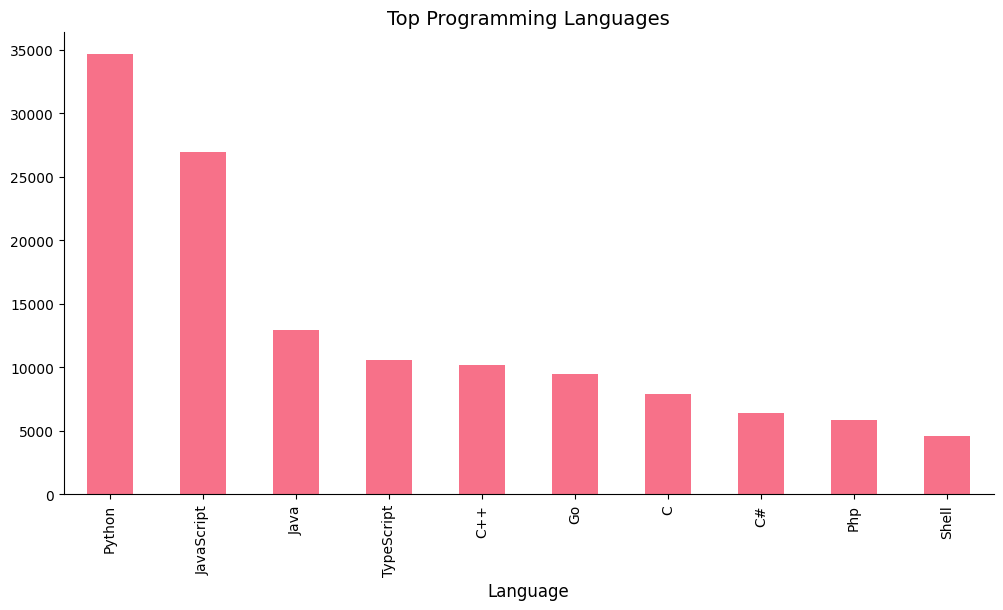

In [25]:
df["Language"].value_counts().head(10).plot(kind="bar")
plt.title("Top Programming Languages")
plt.show()

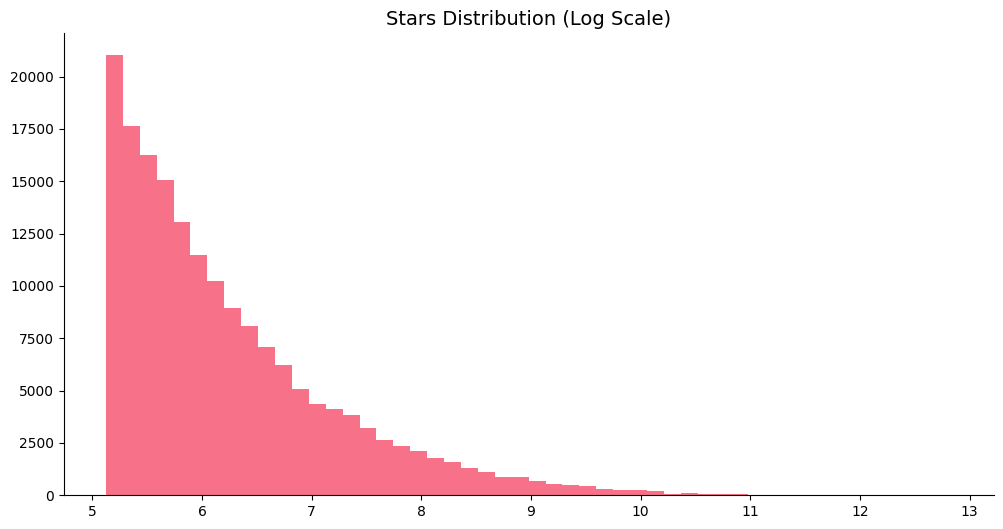

In [26]:
plt.hist(df["Stars_log"], bins=50)
plt.title("Stars Distribution (Log Scale)")
plt.show()

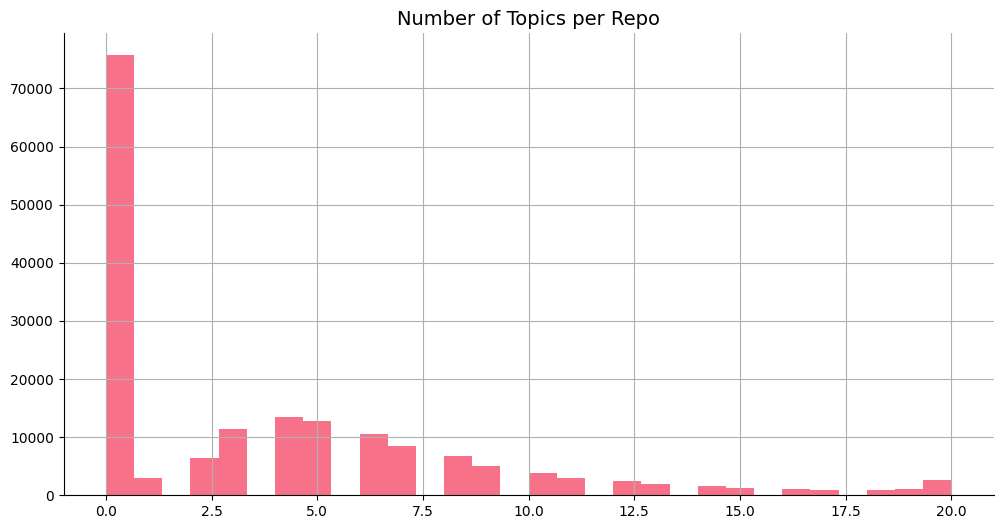

In [27]:
df["Topics"].apply(len).hist(bins=30)
plt.title("Number of Topics per Repo")
plt.show()

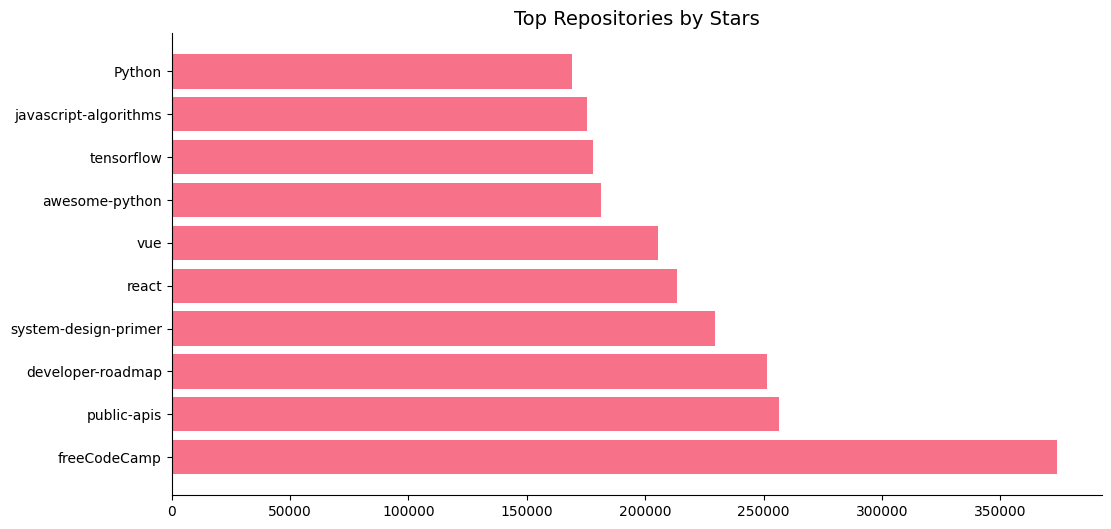

In [28]:
top = df.sort_values(by="Stars", ascending=False).head(10)

plt.barh(top["Name"], top["Stars"])
plt.title("Top Repositories by Stars")
plt.show()

## Data Sampling & Filtering

In [29]:
# ============================================================
# Step 1 — Filter Weak Repositories
# Remove low-quality repos based on:
# - Stars threshold
# - Minimum number of topics
# ============================================================

df_clean = df[
    (df['Stars'] >= 50) &
    (df['Topics'].apply(lambda x: len(x) >= 2))
].copy()

print(f"Clean pool: {df_clean.shape[0]} repositories")

Clean pool: 95312 repositories


In [30]:
# ============================================================
# Step 2 — Hybrid Sampling
# Combine:
# - Top repositories (by stars)
# - Random sample (for diversity)
# ============================================================

# Top repositories
top_df = df_clean.sort_values('Stars', ascending=False).head(1500)

# Remaining repositories (excluding top ones)
remaining_df = df_clean[~df_clean['URL'].isin(top_df['URL'])]

# Random sample from remaining
random_df = remaining_df.sample(
    min(1500, len(remaining_df)),
    random_state=42
)

# Merge both samples and remove duplicates
df_sample = pd.concat([top_df, random_df]).drop_duplicates(subset=['URL'])

print(f"Sample size before shuffle: {df_sample.shape[0]}")

Sample size before shuffle: 3000


In [31]:
# ============================================================
# Step 3 — Shuffle & Generate Insights
# ============================================================

# Shuffle dataset for better distribution
df_sample = df_sample.sample(frac=1, random_state=42).reset_index(drop=True)

# Basic statistics
print(f"✅ Final sample: {df_sample.shape[0]} repositories")
print(f"Stars range: {df_sample['Stars'].min()} → {df_sample['Stars'].max()}")

# Insight: Average number of topics
avg_topics = df_sample['Topics'].apply(len).mean()
print(f"Average topics per repo: {avg_topics:.2f}")

# Language distribution
print("\nTop Programming Languages:")
print(df_sample['Language'].value_counts().head(10))

✅ Final sample: 3000 repositories
Stars range: 167 → 374074
Average topics per repo: 7.98

Top Programming Languages:
Language
Python        576
JavaScript    468
TypeScript    362
Go            272
Java          198
C++           155
Rust           98
C#             97
C              86
Php            79
Name: count, dtype: int64


In [32]:
# Create grouped language column (for visualization only)
top_langs = df_sample['Language'].value_counts().head(9).index

df_sample['Language_Grouped'] = df_sample['Language'].apply(
    lambda x: x if x in top_langs else 'Other'
)

print(df_sample['Language_Grouped'].value_counts())

Language_Grouped
Other         688
Python        576
JavaScript    468
TypeScript    362
Go            272
Java          198
C++           155
Rust           98
C#             97
C              86
Name: count, dtype: int64


In [33]:
df_sample.to_csv("sample_ready.csv", index=False)

##build graph

In [34]:
# Graph Construction

import networkx as nx
from collections import defaultdict
from itertools import combinations

G = nx.Graph()

print("GRAPH CONSTRUCTION STARTED\n")

# Add repository nodes
for _, row in df_sample.iterrows():
    G.add_node(
        row["URL"],
        name=row["Name"],
        stars=row["Stars"],
        language=row["Language_Grouped"],
        topics=row["Clean_Topics"]
    )

print(f"[1] Total nodes added: {G.number_of_nodes()}")

# Build topic-to-repositories mapping
topic_to_repos = defaultdict(list)

for _, row in df_sample.iterrows():
    for topic in set(row["Clean_Topics"]):
        topic_to_repos[topic].append(row["URL"])

print(f"[2] Unique topics found: {len(topic_to_repos)}")

# Compute shared-topic edge weights
edge_weights = defaultdict(int)

for topic, repos in topic_to_repos.items():
    for repo1, repo2 in combinations(repos, 2):
        if repo1 != repo2:
            edge = tuple(sorted((repo1, repo2)))
            edge_weights[edge] += 1

print(f"[3] Candidate edges (before filtering): {len(edge_weights)}")

# Add weighted edges
MIN_SHARED_TOPICS = 2
edges_added = 0

for (repo1, repo2), weight in edge_weights.items():
    if weight >= MIN_SHARED_TOPICS:
        G.add_edge(repo1, repo2, weight=weight)
        edges_added += 1

print(f"[4] Edges added (weight >= {MIN_SHARED_TOPICS}): {edges_added}")
print(f"Graph → Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}")

# Remove isolated nodes
isolated_nodes = list(nx.isolates(G))
print(f"[5] Isolated nodes found: {len(isolated_nodes)}")

G.remove_nodes_from(isolated_nodes)

print(f"After removal → Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}")

# Final graph statistics
print("\nFINAL GRAPH STATISTICS\n")
print(f"Nodes   : {G.number_of_nodes()}")
print(f"Edges   : {G.number_of_edges()}")
print(f"Density : {nx.density(G):.6f}")
print("\nGraph construction completed")

GRAPH CONSTRUCTION STARTED

[1] Total nodes added: 3000
[2] Unique topics found: 9684
[3] Candidate edges (before filtering): 306869
[4] Edges added (weight >= 2): 37946
Graph → Nodes: 3000, Edges: 37946
[5] Isolated nodes found: 512
After removal → Nodes: 2488, Edges: 37946

FINAL GRAPH STATISTICS

Nodes   : 2488
Edges   : 37946
Density : 0.012265

Graph construction completed


In [35]:
import pickle

with open("graph.pkl", "wb") as f:
    pickle.dump(G, f)

##🧠 PageRank Analysis

In [36]:
# PageRank Analysis

print("PAGERANK ANALYSIS\n")

# Compute PageRank scores
pagerank_scores = nx.pagerank(G, weight='weight', alpha=0.85)

print(f"[1] PageRank computed for {len(pagerank_scores)} repositories")

# Convert scores to DataFrame
pr_df = pd.DataFrame(
    list(pagerank_scores.items()),
    columns=["URL", "PageRank_Score"]
).sort_values("PageRank_Score", ascending=False)

# Merge with repository metadata
repo_metadata = df_sample[["URL", "Name", "Stars", "Language_Grouped"]].drop_duplicates(subset=["URL"])
pr_df = pr_df.merge(repo_metadata, on="URL")

# Display top repositories
print("\nTop 20 Influential Repositories:\n")

for rank, (_, row) in enumerate(pr_df.head(20).iterrows(), 1):
    print(f"{rank}. {row['Name']:<35} | Score: {row['PageRank_Score']:.6f} | Stars: {row['Stars']:,}")

# Rank comparison (PageRank vs Stars)
pr_df["Rank_PR"] = pr_df["PageRank_Score"].rank(ascending=False)
pr_df["Rank_Stars"] = pr_df["Stars"].rank(ascending=False)
pr_df["Rank_Difference"] = pr_df["Rank_Stars"] - pr_df["Rank_PR"]

print("\nHidden Gems (High PageRank vs Low Stars):\n")

hidden_gems = pr_df.nlargest(10, "Rank_Difference")

for _, row in hidden_gems.iterrows():
    print(f"{row['Name']:<40} | PR Rank: {int(row['Rank_PR'])} | Stars Rank: {int(row['Rank_Stars'])} | Diff: {int(row['Rank_Difference'])}")

print("\nOverrated Repos (High Stars vs Low PageRank):\n")

overrated = pr_df.nsmallest(10, "Rank_Difference")

for _, row in overrated.iterrows():
    print(f"{row['Name']:<40} | PR Rank: {int(row['Rank_PR'])} | Stars Rank: {int(row['Rank_Stars'])} | Diff: {int(row['Rank_Difference'])}")

# Correlation
corr_value = pr_df["Stars"].corr(pr_df["PageRank_Score"])
print(f"\nCorrelation (Stars vs PageRank): {corr_value:.4f}")

PAGERANK ANALYSIS

[1] PageRank computed for 2488 repositories

Top 20 Influential Repositories:

1. NativeScript                        | Score: 0.003905 | Stars: 22,976
2. 30-Days-Of-JavaScript               | Score: 0.002892 | Stars: 38,463
3. novu                                | Score: 0.002657 | Stars: 24,441
4. storybook                           | Score: 0.002603 | Stars: 80,398
5. pulumi                              | Score: 0.002546 | Stars: 17,581
6. nx                                  | Score: 0.002517 | Stars: 19,333
7. expo                                | Score: 0.002292 | Stars: 23,452
8. ionic-framework                     | Score: 0.002291 | Stars: 49,487
9. ToolJet                             | Score: 0.002277 | Stars: 20,497
10. transformers                        | Score: 0.002276 | Stars: 112,153
11. sheetjs                             | Score: 0.002249 | Stars: 33,577
12. fe-interview                        | Score: 0.002223 | Stars: 23,967
13. strapi            

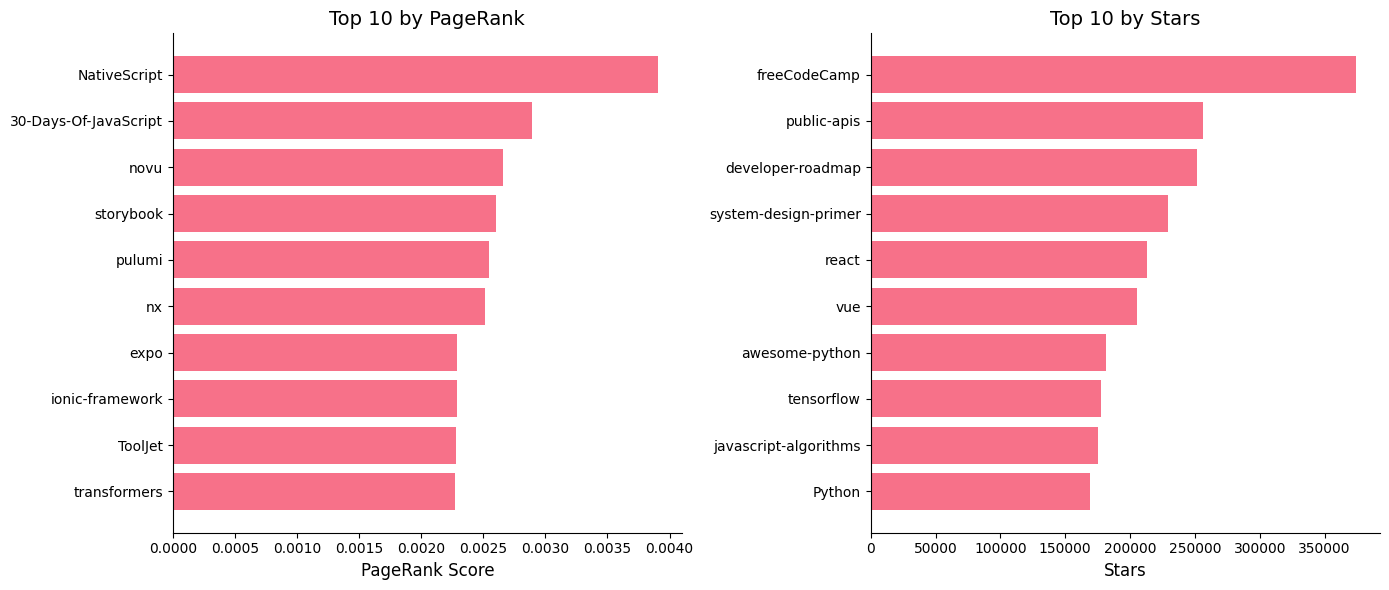

PageRank visualization completed


In [37]:
# PageRank Visualization

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Top 10 by PageRank
top10_pr = pr_df.head(10)
axes[0].barh(top10_pr["Name"], top10_pr["PageRank_Score"])
axes[0].invert_yaxis()
axes[0].set_title("Top 10 by PageRank")
axes[0].set_xlabel("PageRank Score")

# Top 10 by Stars
top10_stars = pr_df.nlargest(10, "Stars")
axes[1].barh(top10_stars["Name"], top10_stars["Stars"])
axes[1].invert_yaxis()
axes[1].set_title("Top 10 by Stars")
axes[1].set_xlabel("Stars")

plt.tight_layout()
plt.show()

print("PageRank visualization completed")

In [38]:
# Save results for GUI later

pr_df.to_csv("pagerank_results.csv", index=False)
df_sample.to_csv("sample_data.csv", index=False)

# Light version for faster GUI
pr_df[['URL', 'Name', 'PageRank_Score', 'Stars']].to_csv("pagerank_light.csv", index=False)

print("Data saved successfully for GUI")

Data saved successfully for GUI


In [39]:
# Graph Validation / Sanity Check

print("GRAPH VALIDATION / SANITY CHECK\n")

# 1. Most connected repositories (highest degree)
degrees = dict(G.degree())
top_degree = sorted(degrees.items(), key=lambda x: x[1], reverse=True)[:10]

print("Top 10 Most Connected Repositories:\n")
for rank, (url, degree) in enumerate(top_degree, 1):
    repo = df_sample[df_sample["URL"] == url].iloc[0]
    print(f"{rank}. {repo['Name']:<35} | Degree: {degree:<4} | Stars: {repo['Stars']:,}")

# 2. Compare suspicious repositories
print("\nRepository Comparison:\n")

check_repos = ["NativeScript", "freeCodeCamp"]

for repo_name in check_repos:
    repo_row = df_sample[df_sample["Name"] == repo_name].iloc[0]
    url = repo_row["URL"]

    degree = G.degree(url)
    topics_count = len(repo_row["Clean_Topics"])
    pr_score = pr_df[pr_df["URL"] == url]["PageRank_Score"].values[0]

    print(f"{repo_name}")
    print(f"  Stars      : {repo_row['Stars']:,}")
    print(f"  Degree     : {degree}")
    print(f"  Topics     : {topics_count}")
    print(f"  PageRank   : {pr_score:.6f}\n")

# 3. Correlation check
corr_value = pr_df["Stars"].corr(pr_df["PageRank_Score"])

print(f"Correlation (Stars vs PageRank): {corr_value:.4f}")

# 4. Degree vs PageRank quick comparison
degree_df = pd.DataFrame(degrees.items(), columns=["URL", "Degree"])
validation_df = pr_df.merge(degree_df, on="URL")

print("\nTop 10 by Degree vs PageRank:\n")
print(validation_df[["Name", "Degree", "PageRank_Score", "Stars"]]
      .sort_values("Degree", ascending=False)
      .head(10))

GRAPH VALIDATION / SANITY CHECK

Top 10 Most Connected Repositories:

1. NativeScript                        | Degree: 342  | Stars: 22,976
2. 30-Days-Of-JavaScript               | Degree: 279  | Stars: 38,463
3. novu                                | Degree: 277  | Stars: 24,441
4. nx                                  | Degree: 257  | Stars: 19,333
5. storybook                           | Degree: 248  | Stars: 80,398
6. pulumi                              | Degree: 243  | Stars: 17,581
7. ToolJet                             | Degree: 239  | Stars: 20,497
8. sheetjs                             | Degree: 228  | Stars: 33,577
9. fe-interview                        | Degree: 228  | Stars: 23,967
10. strapi                              | Degree: 222  | Stars: 56,105

Repository Comparison:

NativeScript
  Stars      : 22,976
  Degree     : 342
  Topics     : 20
  PageRank   : 0.003905

freeCodeCamp
  Stars      : 374,074
  Degree     : 184
  Topics     : 16
  PageRank   : 0.001653

Correlati

In [40]:
pr_df.to_csv("pagerank.csv", index=False)

#HITS

##HITS Computation

In [41]:
# HITS ANALYSIS (Computation only)

hubs, authorities = nx.hits(G, max_iter=100, tol=1e-08)

hub_df = pd.DataFrame(list(hubs.items()), columns=["URL", "Hub_Score"])
authority_df = pd.DataFrame(list(authorities.items()), columns=["URL", "Authority_Score"])

repo_metadata = df_sample[["URL", "Name", "Stars", "Language_Grouped"]].drop_duplicates(subset=["URL"])

hub_df = hub_df.merge(repo_metadata, on="URL").sort_values("Hub_Score", ascending=False)
authority_df = authority_df.merge(repo_metadata, on="URL").sort_values("Authority_Score", ascending=False)

print("Top 10 Hubs:\n")
print(hub_df[["Name", "Hub_Score", "Stars"]].head(10))

print("\nTop 10 Authorities:\n")
print(authority_df[["Name", "Authority_Score", "Stars"]].head(10))

# Prepare comparison
comparison_df = pr_df.merge(
    hub_df[["URL", "Hub_Score"]], on="URL"
).merge(
    authority_df[["URL", "Authority_Score"]], on="URL"
)

Top 10 Hubs:

                       Name  Hub_Score  Stars
608   30-Days-Of-JavaScript   0.008822  38463
1580                   novu   0.008279  24441
67                       nx   0.007793  19333
528            NativeScript   0.007346  22976
753               storybook   0.006890  80398
648       react-starter-kit   0.006884  22110
1949           fe-interview   0.006511  23967
1354        ionic-framework   0.006496  49487
891                 sheetjs   0.006362  33577
883                     bun   0.006254  61964

Top 10 Authorities:

                       Name  Authority_Score  Stars
608   30-Days-Of-JavaScript         0.008822  38463
1580                   novu         0.008279  24441
67                       nx         0.007793  19333
528            NativeScript         0.007346  22976
753               storybook         0.006890  80398
648       react-starter-kit         0.006884  22110
1949           fe-interview         0.006511  23967
1354        ionic-framework         0.0064

##Top Hubs Plot

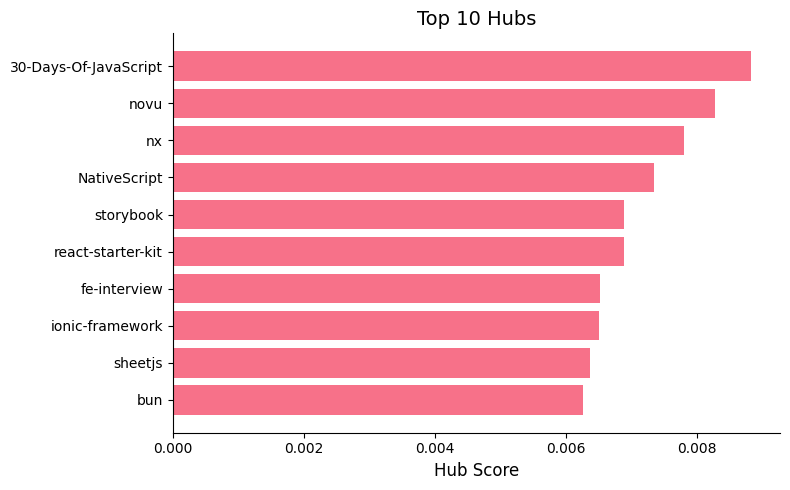

In [42]:
plt.figure(figsize=(8,5))

top_hubs = hub_df.head(10)
plt.barh(top_hubs["Name"], top_hubs["Hub_Score"])

plt.gca().invert_yaxis()
plt.xlabel("Hub Score")
plt.title("Top 10 Hubs")

plt.tight_layout()
plt.show()

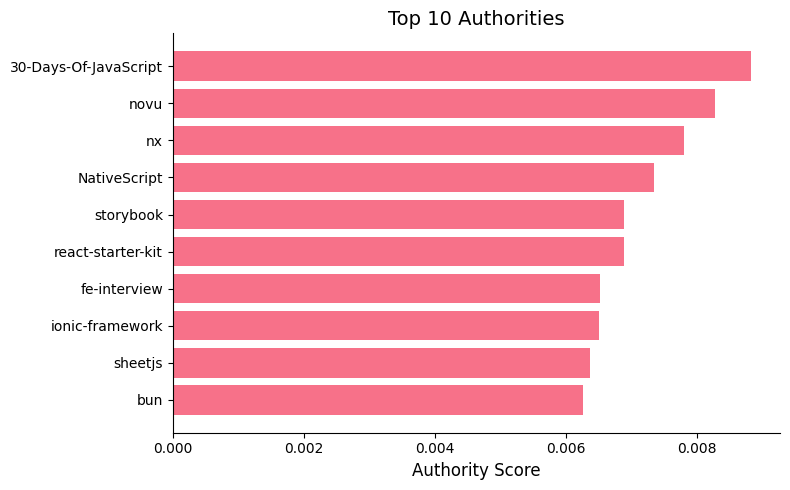

In [43]:
plt.figure(figsize=(8,5))

top_auth = authority_df.head(10)
plt.barh(top_auth["Name"], top_auth["Authority_Score"])

plt.gca().invert_yaxis()
plt.xlabel("Authority Score")
plt.title("Top 10 Authorities")

plt.tight_layout()
plt.show()

In [44]:
corr_hub_pr = comparison_df["Hub_Score"].corr(comparison_df["PageRank_Score"])
corr_auth_pr = comparison_df["Authority_Score"].corr(comparison_df["PageRank_Score"])
corr_hub_auth = comparison_df["Hub_Score"].corr(comparison_df["Authority_Score"])

print("Correlation Results:\n")
print(f"Hub vs PageRank      : {corr_hub_pr:.4f}")
print(f"Authority vs PageRank: {corr_auth_pr:.4f}")
print(f"Hub vs Authority     : {corr_hub_auth:.4f}")

Correlation Results:

Hub vs PageRank      : 0.7165
Authority vs PageRank: 0.7165
Hub vs Authority     : 1.0000


In [45]:
# SAVE HITS RESULTS
hub_df.to_csv("hubs.csv", index=False)
authority_df.to_csv("authorities.csv", index=False)

print("HITS data saved ✅")

HITS data saved ✅


#ASSOCIATION RULES (FP-GROWTH)


In [46]:
# Clean and normalize Tech_Stack

def normalize_item(item):
    item = item.lower().strip()

    # fix synonyms
    if item in ["golang"]:
        return "go"
    if item in ["js"]:
        return "javascript"
    if item in ["reactjs", "react.js"]:
        return "react"

    return item

def clean_transaction(transaction):
    return list(set([normalize_item(x) for x in transaction]))

df_sample["Cleaned_Stack"] = df_sample["Tech_Stack"].apply(clean_transaction)

# Prepare transactions
transactions = df_sample["Cleaned_Stack"].tolist()

print(f"Transactions: {len(transactions)}")
print(f"Sample: {transactions[0][:5]}")

Transactions: 3000
Sample: ['cloud-functions', 'functions-as-a-service', 'google-cloud', 'php']


In [47]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth
import pandas as pd

# One-hot encoding
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

print(f"Unique items: {len(te.columns_)}")

# Run FP-Growth
MIN_SUPPORT = 0.01

frequent_itemsets = fpgrowth(
    df_encoded,
    min_support=MIN_SUPPORT,
    use_colnames=True
)

print(f"Frequent itemsets: {len(frequent_itemsets)}")

Unique items: 9697
Frequent itemsets: 104


In [48]:
from mlxtend.frequent_patterns import association_rules
import matplotlib.pyplot as plt

# Generate rules
rules = association_rules(
    frequent_itemsets,
    metric="lift",
    min_threshold=1.2
)

rules = rules.sort_values("lift", ascending=False)
# Remove generic OS-related rules
exclude_terms = ['linux', 'windows', 'macos']

rules = rules[
    ~rules['antecedents'].apply(lambda x: any(term in x for term in exclude_terms)) &
    ~rules['consequents'].apply(lambda x: any(term in x for term in exclude_terms))
]
print(f"Total rules: {len(rules)}")

# Top rules
print("\nTop 10 Rules:\n")
for _, row in rules.head(10).iterrows():
    print(f"{list(row['antecedents'])} → {list(row['consequents'])}")
    print(f"Lift: {row['lift']:.2f} | Conf: {row['confidence']:.2f} | Supp: {row['support']:.3f}\n")

# Rules for popular technologies
print("\nRules for Popular Technologies:\n")

popular_techs = ['python', 'javascript', 'typescript', 'react']

for tech in popular_techs:
    tech_rules = rules[
        rules['antecedents'].apply(lambda x: tech in x) |
        rules['consequents'].apply(lambda x: tech in x)
    ].head(3)

    print(f"\n--- {tech.upper()} ---")
    if len(tech_rules) > 0:
        for _, row in tech_rules.iterrows():
            print(f"{list(row['antecedents'])} → {list(row['consequents'])}")
            print(f"Lift: {row['lift']:.2f}, Conf: {row['confidence']:.2f}")
    else:
        print("No strong rules found")



Total rules: 72

Top 10 Rules:

['php'] → ['laravel']
Lift: 31.53 | Conf: 0.37 | Supp: 0.011

['laravel'] → ['php']
Lift: 31.53 | Conf: 0.91 | Supp: 0.011

['pytorch'] → ['deep-learning', 'python']
Lift: 17.67 | Conf: 0.57 | Supp: 0.015

['deep-learning', 'python'] → ['pytorch']
Lift: 17.67 | Conf: 0.45 | Supp: 0.015

['swift'] → ['ios']
Lift: 15.81 | Conf: 0.43 | Supp: 0.012

['ios'] → ['swift']
Lift: 15.81 | Conf: 0.43 | Supp: 0.012

['deep-learning'] → ['pytorch']
Lift: 14.57 | Conf: 0.37 | Supp: 0.015

['pytorch'] → ['deep-learning']
Lift: 14.57 | Conf: 0.60 | Supp: 0.015

['pytorch', 'python'] → ['deep-learning']
Lift: 14.50 | Conf: 0.59 | Supp: 0.015

['deep-learning'] → ['pytorch', 'python']
Lift: 14.50 | Conf: 0.36 | Supp: 0.015


Rules for Popular Technologies:


--- PYTHON ---
['pytorch'] → ['deep-learning', 'python']
Lift: 17.67, Conf: 0.57
['deep-learning', 'python'] → ['pytorch']
Lift: 17.67, Conf: 0.45
['pytorch', 'python'] → ['deep-learning']
Lift: 14.50, Conf: 0.59

---

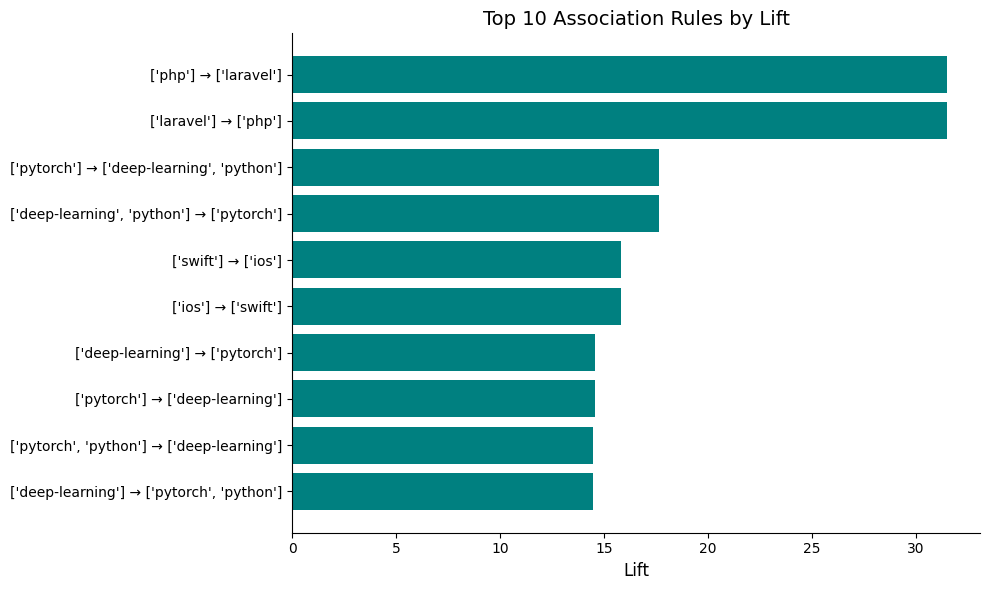

Saved for GUI


In [49]:
# Plot top rules by lift
top_rules = rules.head(10)
rule_names = [f"{list(a)} → {list(c)}" for a, c in zip(top_rules['antecedents'], top_rules['consequents'])]

plt.figure(figsize=(10, 6))
plt.barh(rule_names, top_rules['lift'], color='teal')
plt.gca().invert_yaxis()
plt.xlabel('Lift')
plt.title('Top 10 Association Rules by Lift')
plt.tight_layout()
plt.show()

# Save for GUI
rules.to_csv("association_rules.csv", index=False)

print("Saved for GUI")

In [50]:
# SAVE FP-GROWTH RESULTS
rules.to_csv("rules.csv", index=False)
frequent_itemsets.to_csv("itemsets.csv", index=False)

unique_items_count = len(df_encoded.columns)

print("FP-Growth data saved ✅")

FP-Growth data saved ✅


#BERT

In [51]:
print(df_sample.columns)

Index(['Name', 'Description', 'URL', 'Stars', 'Forks', 'Watchers', 'Language',
       'Topics', 'Stars_log', 'Clean_Description', 'Clean_Topics',
       'Combined_Text', 'Tech_Stack', 'Language_Grouped', 'Cleaned_Stack'],
      dtype='object')


In [52]:
# ============================================================
# BERT ANALYSIS - SETUP + EMBEDDINGS
# ============================================================

import torch
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer

print("=" * 60)
print("BERT ANALYSIS - STEP 1 (EMBEDDINGS)")
print("=" * 60)

# Sample
BERT_SAMPLE_SIZE = 100
bert_df = df_sample.head(BERT_SAMPLE_SIZE).copy()

# ✅ Fix: handle empty text
texts = bert_df['Combined_Text'].fillna(bert_df['Name']).tolist()

print(f"Sample size: {len(texts)}")

# Load model (fast)
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# Generate embeddings
embeddings = embedding_model.encode(
    texts,
    batch_size=32,
    show_progress_bar=True
)

print(f"Embeddings shape: {embeddings.shape}")

BERT ANALYSIS - STEP 1 (EMBEDDINGS)
Sample size: 100


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

Embeddings shape: (100, 384)


In [53]:
# ============================================================
# BERT ANALYSIS - STEP 2 (CLASSIFICATION + SIMILARITY)
# ============================================================

from transformers import pipeline
from sklearn.metrics.pairwise import cosine_similarity

print("=" * 60)
print("STEP 2: ZERO-SHOT CLASSIFICATION")
print("=" * 60)

# Categories
categories = [
    "Machine Learning or Artificial Intelligence",
    "Frontend Web Development",
    "Backend Web Development or API",
    "Mobile Application Development",
    "DevOps or Cloud Infrastructure",
    "Data Science or Data Analytics",
    "Game Development",
    "Cybersecurity or Security Tools",
    "Desktop Application Development"
]

# Load classifier
classifier = pipeline(
    "zero-shot-classification",
    model="typeform/distilbert-base-uncased-mnli",
    device=0 if torch.cuda.is_available() else -1
)

# Batch classification
batch_size = 16
results = []

for i in range(0, len(texts), batch_size):
    batch_texts = texts[i:i+batch_size]

    # Handle empty text
    batch_texts = [t if len(t.strip()) > 10 else "empty repo" for t in batch_texts]

    outputs = classifier(batch_texts, categories, multi_label=False)

    for j, output in enumerate(outputs):
        results.append({
            'Name': bert_df.iloc[i+j]['Name'],
            'Category': output['labels'][0],
            'Confidence': output['scores'][0],
            'Stars': bert_df.iloc[i+j]['Stars'],
            'Language': bert_df.iloc[i+j]['Language_Grouped']
        })

print("Classification done ✅")

classification_df = pd.DataFrame(results)

print("\nCategory Distribution:")
print(classification_df['Category'].value_counts())

STEP 2: ZERO-SHOT CLASSIFICATION


config.json:   0%|          | 0.00/776 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/258 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Classification done ✅

Category Distribution:
Category
Cybersecurity or Security Tools                28
Machine Learning or Artificial Intelligence    26
Data Science or Data Analytics                 25
Desktop Application Development                10
Mobile Application Development                  6
Frontend Web Development                        2
Game Development                                2
Backend Web Development or API                  1
Name: count, dtype: int64


In [54]:
# ============================================================
# Similarity Function
# ============================================================

def find_similar_repos(repo_name, df, embeddings, top_n=5):
    if repo_name not in df['Name'].values:
        print(f"{repo_name} not found!")
        return []

    idx = df[df['Name'] == repo_name].index[0]
    query = embeddings[idx].reshape(1, -1)

    sims = cosine_similarity(query, embeddings)[0]
    indices = sims.argsort()[-top_n-1:-1][::-1]

    return [
        {
            'Name': df.iloc[i]['Name'],
            'Similarity': sims[i],
            'Stars': df.iloc[i]['Stars']
        }
        for i in indices
    ]


# ✅ Fix: use real repo names
test_repos = bert_df['Name'].head(3).tolist()

print("\nSimilarity Examples:")
for repo in test_repos:
    similar = find_similar_repos(repo, bert_df, embeddings)
    print(f"\nSimilar to '{repo}':")
    for i, r in enumerate(similar, 1):
        print(f"  {i}. {r['Name']} | Sim: {r['Similarity']:.4f}")


Similarity Examples:

Similar to 'functions-framework-php':
  1. ethereum-php | Sim: 0.3487
  2. awesome-cheatsheets | Sim: 0.3067
  3. FsHttp | Sim: 0.2885
  4. qiankun | Sim: 0.2841
  5. hydra | Sim: 0.2634

Similar to 'data-engineering-zoomcamp':
  1. redash | Sim: 0.4905
  2. streamlit | Sim: 0.3930
  3. luigi | Sim: 0.3891
  4. metabase | Sim: 0.3812
  5. grafana | Sim: 0.3764

Similar to 'nats-top':
  1. grafana | Sim: 0.3728
  2. PowerShell_IPv4NetworkScanner | Sim: 0.3699
  3. frp | Sim: 0.3491
  4. metabase | Sim: 0.3279
  5. Rocket.Chat | Sim: 0.3039


STEP 3: t-SNE VISUALIZATION


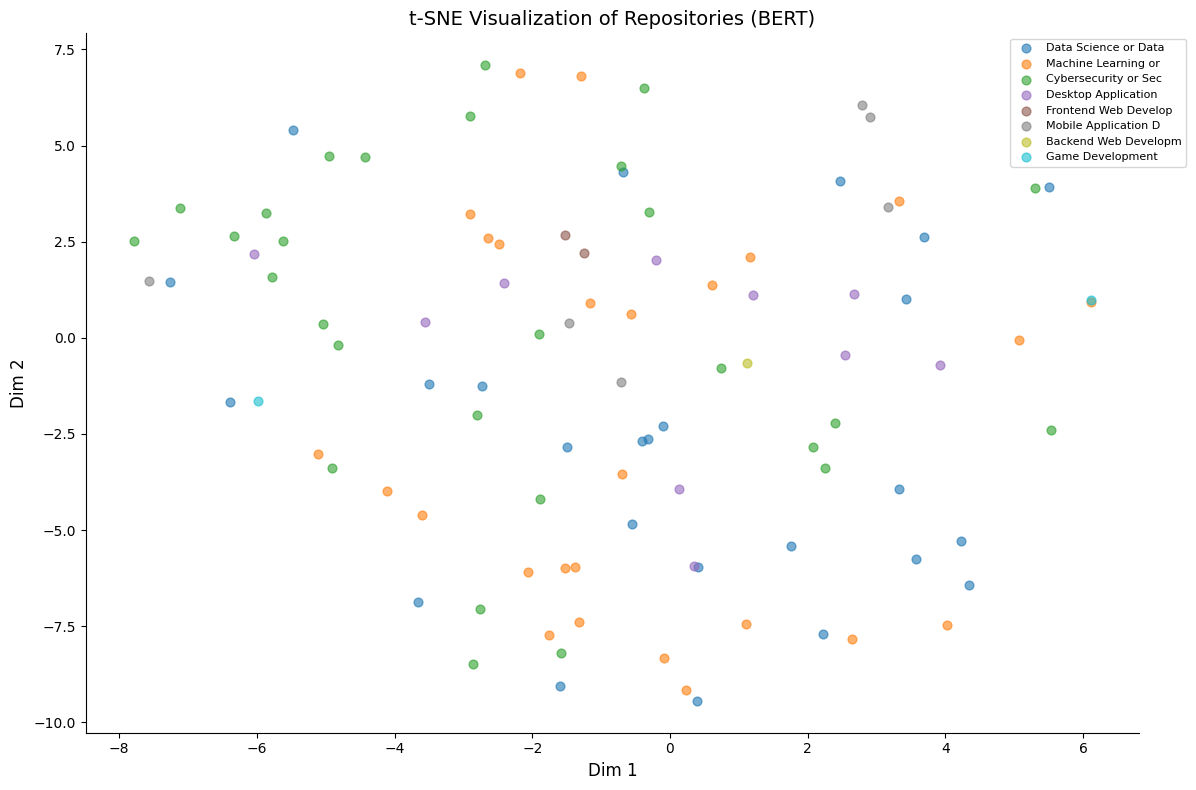

In [55]:
# ============================================================
# BERT ANALYSIS - STEP 3 (VISUALIZATION + SAVE)
# ============================================================

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

print("=" * 60)
print("STEP 3: t-SNE VISUALIZATION")
print("=" * 60)

# t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embeddings_2d = tsne.fit_transform(embeddings)

plt.figure(figsize=(12, 8))

colors = plt.cm.tab10(np.linspace(0, 1, len(classification_df['Category'].unique())))

# ✅ Fix: correct indexing
for i, category in enumerate(classification_df['Category'].unique()):
    indices = classification_df[classification_df['Category'] == category].index

    plt.scatter(
        embeddings_2d[indices, 0],
        embeddings_2d[indices, 1],
        color=colors[i],
        label=category[:20],
        alpha=0.6,
        s=40
    )

plt.title("t-SNE Visualization of Repositories (BERT)")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.legend(bbox_to_anchor=(1.05, 1), fontsize=8)
plt.tight_layout()
plt.show()

In [56]:
# ============================================================
# Summary + Save
# ============================================================

print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)

print(f"Total repos: {len(classification_df)}")
print(f"Categories: {classification_df['Category'].nunique()}")
print(f"Avg confidence: {classification_df['Confidence'].mean():.3f}")

print("\nTop Categories:")
print(classification_df['Category'].value_counts().head())

# ✅ Save results
classification_df.to_csv("classification_results.csv", index=False)
bert_df.to_csv("bert_data.csv", index=False)
np.save("embeddings.npy", embeddings)

print("\n✅ Results saved (CSV + NPY)")


SUMMARY
Total repos: 100
Categories: 8
Avg confidence: 0.322

Top Categories:
Category
Cybersecurity or Security Tools                28
Machine Learning or Artificial Intelligence    26
Data Science or Data Analytics                 25
Desktop Application Development                10
Mobile Application Development                  6
Name: count, dtype: int64

✅ Results saved (CSV + NPY)
